In [81]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.linear_model import Ridge
from sklearn.pipeline import Pipeline
from scipy.stats import uniform, randint

In [82]:
df_origin = pd.read_csv(r'C:\Users\raibe\Desktop\full-flow\preprocessed data\feature_engineered_anime_alt.csv')

In [83]:
df = df_origin.copy()

In [84]:
pd.set_option('display.max_columns', None)

In [85]:
print(type(df))

<class 'pandas.DataFrame'>


In [86]:
numerical = df.select_dtypes(include=np.number).columns
categorical = df.select_dtypes(exclude=np.number).columns

In [88]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant

X = add_constant(df[numerical])

vif_data = pd.DataFrame()
vif_data["feature"] = X.columns
vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(len(X.columns))]


vif_result = vif_data[vif_data['feature'] != 'const'].sort_values(by="VIF", ascending=False)

print(vif_result)

              feature        VIF
5         recommended        inf
6      mixed_feelings        inf
15          rec_share        inf
17      not_rec_share        inf
7     not_recommended        inf
11            reviews        inf
18  sentiment_balance        inf
4             members  85.192635
2       people_scored  75.054906
10          favorites   5.345221
12          favs_rate   3.216645
3          popularity   2.978601
1               score   2.521072
14        scored_rate   1.584917
13        desc_length   1.465923
16          mix_share   1.315759
8        duration_min   1.132219
9            episodes   1.080721


c:\Python312\Lib\site-packages\statsmodels\stats\outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)


In [89]:
df = df.drop(columns=['sentiment_balance', 'recommended', 'members', 'reviews'])

In [90]:
numerical = df.select_dtypes(include=np.number).columns

In [91]:
X = add_constant(df[numerical])

vif_data = pd.DataFrame()
vif_data["feature"] = X.columns
vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(len(X.columns))]


vif_result = vif_data[vif_data['feature'] != 'const'].sort_values(by="VIF", ascending=False)

print(vif_result)

            feature       VIF
4    mixed_feelings  8.466852
5   not_recommended  5.794046
2     people_scored  4.759821
8         favorites  3.692846
9         favs_rate  2.921629
3        popularity  2.630883
1             score  2.520300
12        rec_share  1.655127
11      scored_rate  1.548447
10      desc_length  1.451997
14    not_rec_share  1.317195
13        mix_share  1.285385
6      duration_min  1.123925
7          episodes  1.073561


In [92]:
df.head()

,title,score,people_scored,popularity,season,studio,description,mixed_feelings,not_recommended,rec,mix,not_rec,show_type,status,aired,source,genres,duration_min,episodes,rating,favorites,favs_rate,desc_length,scored_rate,rec_share,mix_share,not_rec_share
0,sousou no frieren,9.27,869731,104,fall 2023,madhouse,during their decade-long quest to defeat the d...,144,116,i feel so catered to.\r\n\r\nit feels like an ...,someone recommended me to watch this title las...,style-\r\nfrieren doesn't have its own unique ...,tv,finished airing,"sep 29, 2023 to mar 22, 2024",manga,"adventure, award winning, drama, fantasy",24.0,28.0,pg-13 - teens 13 or older,88070,0.062400,1099,0.616229,0.759036,0.133457,0.107507
1,steel ball run: jojo no kimyou na bouken,9.16,86411,1447,spring 2026,david production,"in the american old west, the world's greatest...",7,1,i watched the first episode and it was truly a...,i will summarize it for you in two words.\r\nn...,the part 7 adaption is similar to its previous...,ona,currently airing,"mar 19, 2026 to ?",manga,"action, adventure, mystery, supernatural",47.0,11.0,r - 17+ (violence & profanity),6051,0.031859,1194,0.454965,0.951220,0.042683,0.006098
2,fullmetal alchemist: brotherhood,9.11,2303444,3,spring 2009,bones,after a horrific alchemy experiment goes wrong...,69,44,"first of all, i have seen the original fma and...",fullmetal alchemist: brotherhood gets an immen...,*spoiler warning\r\n\r\naside from the usual e...,tv,finished airing,"apr 5, 2009 to jul 4, 2010",manga,"action, adventure, drama, fantasy",24.0,64.0,r - 17+ (violence & profanity),241796,0.065924,1169,0.628020,0.895756,0.063653,0.040590
3,chainsaw man movie: reze-hen,9.09,282353,589,fall 2025,mappa,despite the immediate challenges following bec...,46,19,in short if you like and read the chainsaw man...,quick little review because i feel my perspect...,writing this review to compile my thoughts on ...,movie,finished airing,"sep 19, 2025",manga,"action, fantasy",99.0,1.0,r - 17+ (violence & profanity),12951,0.028830,865,0.628552,0.832041,0.118863,0.049096
4,steins;gate,9.07,1516022,14,spring 2011,white fox,eccentric scientist rintarou okabe has a never...,88,84,“no one knows what the future holds. that’s wh...,one word: hype.\r\n\r\nbefore watching this sh...,just a horrible anime. this is the anime equiv...,tv,finished airing,"apr 6, 2011 to sep 14, 2011",visual novel,"drama, sci-fi, suspense",24.0,24.0,pg-13 - teens 13 or older,201780,0.072011,1144,0.541033,0.862069,0.070569,0.067362


In [93]:
source_mapping = {
    'manga': 'manga_source', 'web manga': 'manga_source', '4-koma manga': 'manga_source',
    'novel': 'book_source', 'light novel': 'book_source', 'web novel': 'book_source',
    'book': 'book_source', 'picture book': 'book_source',
    'game': 'game_source', 'visual novel': 'game_source', 'card game': 'game_source',
    'original': 'original',
    'other': 'other_source', 'unknown': 'other_source', 'mixed media': 'other_source',
    'music': 'other_source', 'radio': 'other_source'
}

df['source_grouped'] = df['source'].map(source_mapping)

In [94]:
encoded = ['show_type', 'status', 'source_grouped']

In [95]:
X_train, X_test, y_train, y_test = train_test_split(df.drop(columns='score'), df['score'], test_size=0.15, random_state=42)

In [96]:
num_cols = numerical.tolist()
num_cols.remove('score')

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore'), encoded)
    ],
    remainder='drop'
)

In [97]:
pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', Ridge())
])

In [98]:
param_distributions = {
    'regressor__alpha': uniform(0.1, 100),
    'regressor__solver': ['svd', 'cholesky', 'lsqr', 'sag']
}

In [99]:
random_search = RandomizedSearchCV(
    estimator=pipeline,
    param_distributions=param_distributions,
    n_iter=50,
    cv=5,
    scoring='r2',
    verbose=1,
    random_state=42,
    n_jobs=-1
)
random_search.fit(X_train, y_train)

Fitting 5 folds for each of 50 candidates, totalling 250 fits


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","Pipeline(step...r', Ridge())])"
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'regressor__alpha': <scipy.stats....001E6001410A0>, 'regressor__solver': ['svd', 'cholesky', ...]}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",50
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'r2'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` def

In [ ]:
print(f"Best params: {random_search.best_params_}")

Best params: {'regressor__alpha': np.float64(14.192422497476263), 'regressor__solver': 'lsqr'}


In [101]:
best_model = random_search.best_estimator_
y_pred = best_model.predict(X_test)
print(f"R2 score: {r2_score(y_test, y_pred):.4f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_pred)):.4f}")

R2 score: 0.6294
RMSE: 0.3709


In [102]:
rf_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', RandomForestRegressor(random_state=42, n_jobs=-1))
])

In [103]:
param_dist_rf = {
    'regressor__n_estimators': randint(100, 500),
    'regressor__max_depth': [None, 10, 20, 30, 50],
    'regressor__min_samples_split': randint(2, 11),
    'regressor__min_samples_leaf': randint(1, 5),
    'regressor__max_features': ['sqrt', 'log2', None]
}

In [104]:
random_search_rf = RandomizedSearchCV(
    estimator=rf_pipeline,
    param_distributions=param_dist_rf,
    n_iter=20,
    cv=3,
    scoring='r2',
    verbose=2,
    random_state=42,
    n_jobs=-1
)
random_search_rf.fit(X_train, y_train)

Fitting 3 folds for each of 20 candidates, totalling 60 fits


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'regressor__max_depth': [None, 10, ...], 'regressor__max_features': ['sqrt', 'log2', ...], 'regressor__min_samples_leaf': <scipy.stats....001E602CCEF30>, 'regressor__min_samples_split': <scipy.stats....001E602CCEC60>, ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",20
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'r2'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Ref

In [105]:
print(f"Best RF params: {random_search_rf.best_params_}")
best_rf_model = random_search_rf.best_estimator_

Best RF params: {'regressor__max_depth': 30, 'regressor__max_features': 'sqrt', 'regressor__min_samples_leaf': 1, 'regressor__min_samples_split': 4, 'regressor__n_estimators': 463}


In [106]:
y_pred_rf = best_rf_model.predict(X_test)
print(f"Random Forest R2: {r2_score(y_test, y_pred_rf):.4f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_pred_rf)):.4f}")

Random Forest R2: 0.7189
RMSE: 0.3230


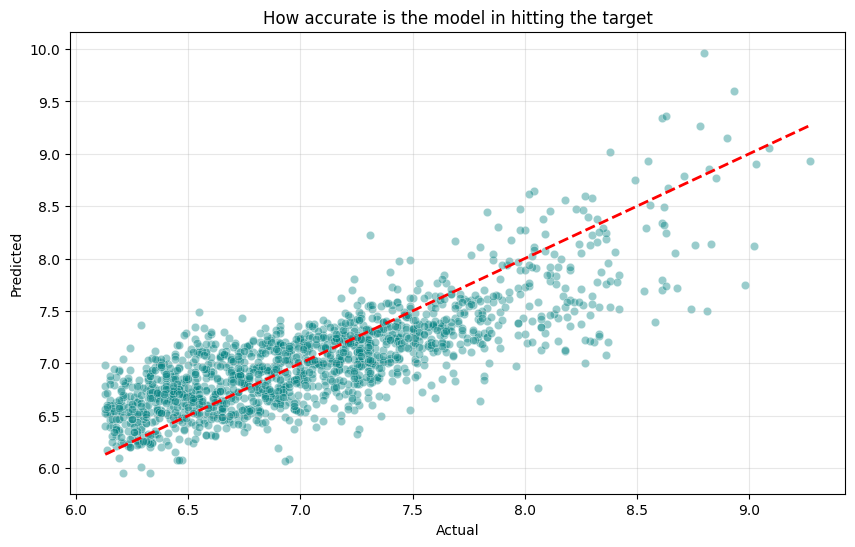

In [107]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_test, y=y_pred, alpha=0.4, color='teal')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], '--r', lw=2)

plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.title('How accurate is the model in hitting the target')
plt.grid(True, alpha=0.3)
plt.show()

C:\Users\raibe\AppData\Local\Temp\ipykernel_70192\1232900943.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='importance', y='feature', data=feat_imp_df.head(15), palette='viridis')


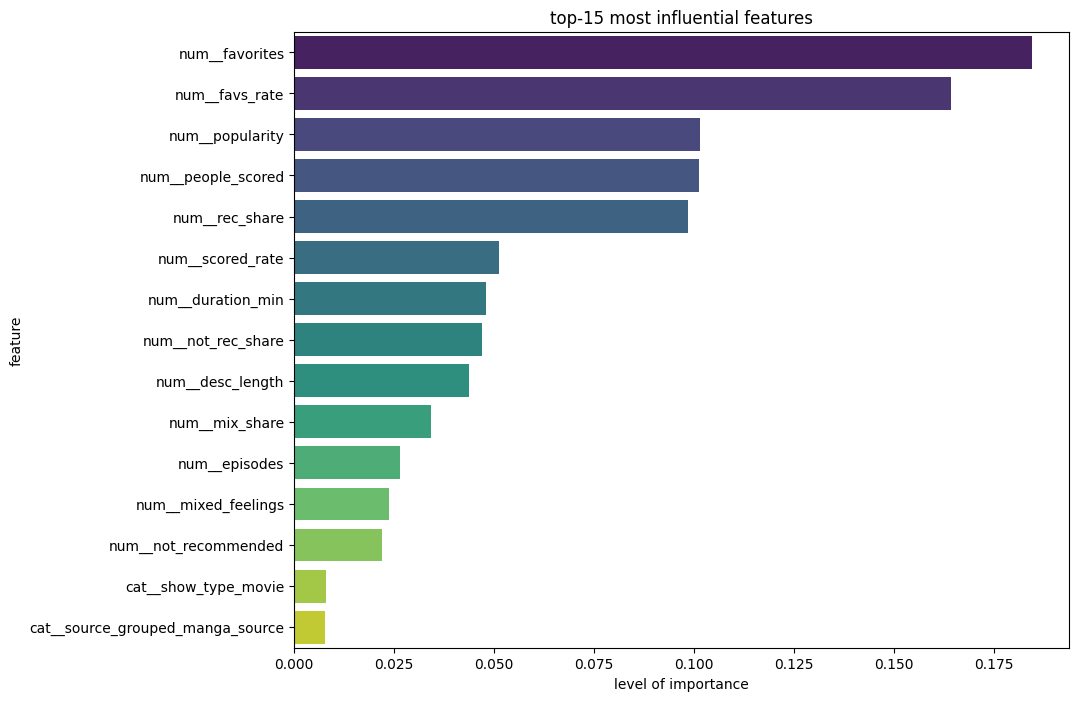

In [108]:
feature_names = best_rf_model.named_steps['preprocessor'].get_feature_names_out()
importances = best_rf_model.named_steps['regressor'].feature_importances_

feat_imp_df = pd.DataFrame({
    'feature': feature_names,
    'importance': importances
}).sort_values(by='importance', ascending=False)

plt.figure(figsize=(10, 8))
sns.barplot(x='importance', y='feature', data=feat_imp_df.head(15), palette='viridis')
plt.title('top-15 most influential features')
plt.xlabel('level of importance')
plt.ylabel('feature')
plt.show()